# Smart Room Optimal Temperature Prediction

This notebook trains a Machine Learning model to predict the optimal indoor temperature based on environmental conditions (`outside_temp`, `outside_humidity`, `outdoor_light`).

We follow the 8 steps of Machine Learning:
1. Data Cleaning and Formatting
2. Exploratory Data Analysis (EDA)
3. Feature Engineering and Selection
4. Establish a Baseline and Compare Models
5. Hyperparameter Tuning
6. Evaluate the Best Model on the Testing Set
7. Interpret Model Results
8. Draw Conclusions and Write a Report

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Set plotting style
plt.style.use('default')
sns.set_theme(style="whitegrid")

## 1. Data Cleaning and Formatting

We will load our dataset from the local `historical_temp_data.csv` file, which maps environmental conditions to a user's target indoor temperature.

In [39]:
# Load historical data
df = pd.read_csv('historical_temp_data.csv')
print("Shape before cleaning:", df.shape)

# 1. Drop missing values (Data Cleaning)
df = df.dropna()

# 2. Formatting (Ensure types are correct - float32)
df = df.astype('float32')

print("Shape after cleaning:", df.shape)
df.head()

Shape before cleaning: (12000, 4)
Shape after cleaning: (11950, 4)


,outside_temp,outside_humidity,outdoor_light,target_indoor_temp
0,11.854305,72.344505,479.869598,21.853657
1,37.782143,26.402605,327.299683,20.093634
2,27.939728,39.386383,38.994827,21.246128
3,21.939632,81.894348,642.957092,19.961792
4,2.020839,62.294868,686.230408,21.364363


## 2. Exploratory Data Analysis (EDA):
The dataset's characteristics are summarized, and outdoor light values are scaled to 0–700 to match a standard Arduino LDR sensor range.

,outside_temp,outside_humidity,outdoor_light,target_indoor_temp
count,11950.000000,11950.000000,11950.000000,11950.000000
mean,17.319279,60.527882,347.086792,21.439947
std,12.970987,23.102531,200.990616,2.206417
min,-4.999476,20.003849,0.003876,14.993423
25%,6.113594,40.605640,172.108906,19.726546
50%,17.208755,60.724733,348.507385,21.461708
75%,28.498292,80.538836,517.579193,23.127209
max,39.987297,99.993988,699.852539,27.647966


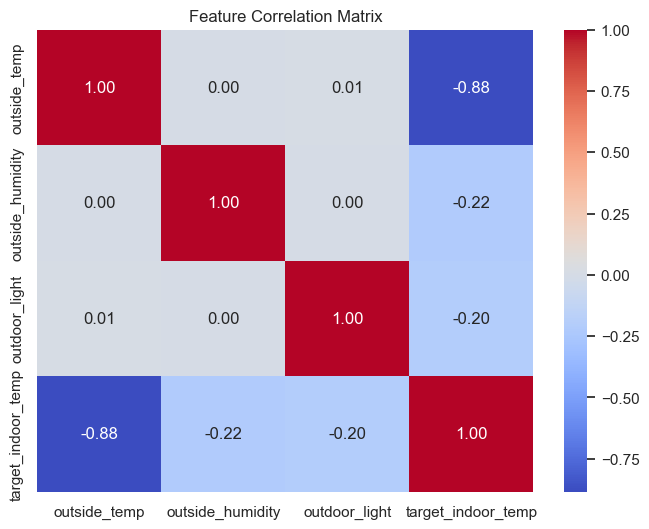

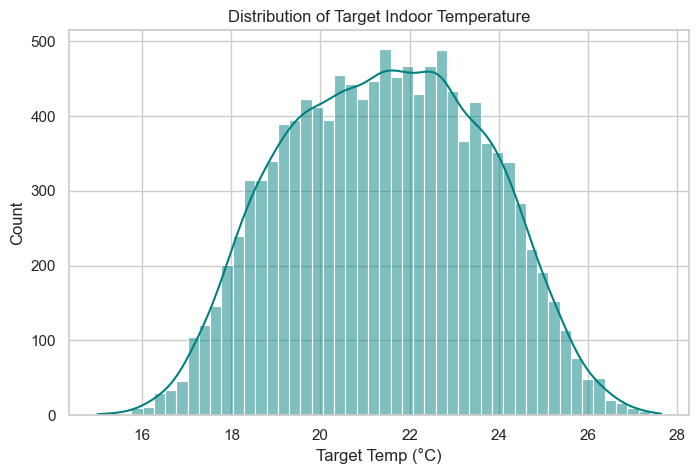

In [21]:
# Descriptive statistics
display(df.describe())

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

# Distribution of Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['target_indoor_temp'], bins=50, kde=True, color='teal')
plt.title('Distribution of Target Indoor Temperature')
plt.xlabel('Target Temp (°C)')
plt.show()

## 3. Feature Engineering and Selection

We use our three raw continuous features for this problem. We split data into features `X` and target `y`, then split into training and testing sets.

In [40]:
# Define Features (X) and Target (y)
X = df[['outside_temp', 'outside_humidity', 'outdoor_light']]
y = df['target_indoor_temp']

# Split 10,000 for training, the rest for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=10000, random_state=42)

print("Training Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])

Training Set Size: 10000
Testing Set Size: 1950


## 4. Establish a Baseline and Compare Models

We calculate the performance of a naive 'Baseline' model (predicting the mean training target always) to know what a bad score is. Then, we test a few default models to find the best candidate.

In [41]:
# 1. Naive Baseline (predict the mean)
baseline_pred = np.full_like(y_test, fill_value=y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Naive Baseline MAE: {baseline_mae:.4f} °C")

# 2. Candidate Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    print(f"{name} MAE: {mae:.4f} °C")

Naive Baseline MAE: 1.8363 °C
Linear Regression MAE: 0.6462 °C
Random Forest MAE: 0.6862 °C
Gradient Boosting MAE: 0.6518 °C


## 5. Hyperparameter Tuning

We select **Linear Regression** as our production model. For linear models, hyperparameter tuning is performed via **Regularization** using **Ridge Regression** (also called L2 Regularization). Ridge adds a penalty term controlled by `alpha` to prevent overfitting — a larger `alpha` adds more constraint.

We search across a range of `alpha` values using **5-fold Cross-Validation** to find the optimal regularization strength.

Alpha=  0.0001 | CV MAE: 0.6410816550 °C
Alpha=   0.001 | CV MAE: 0.6410816550 °C
Alpha=    0.01 | CV MAE: 0.6410816550 °C
Alpha=     0.1 | CV MAE: 0.6410816550 °C
Alpha=     1.0 | CV MAE: 0.6410816073 °C
Alpha=    10.0 | CV MAE: 0.6410815835 °C
Alpha=   100.0 | CV MAE: 0.6410809636 °C

Best Alpha: 100.0


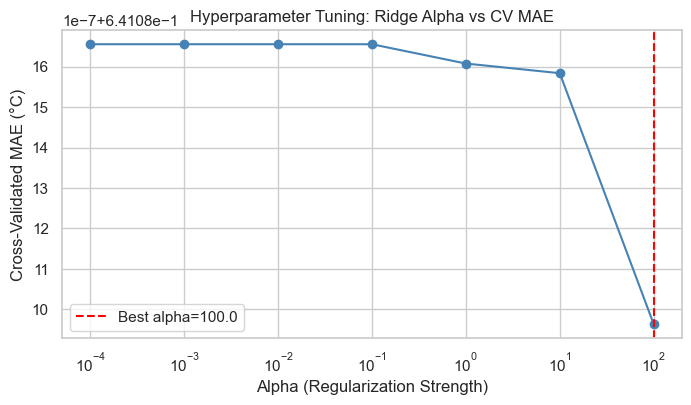

In [43]:
# Search for optimal alpha (regularization strength) using cross-validation
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
cv_scores = []

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_train, y_train,
                             cv=5, scoring='neg_mean_absolute_error')
    cv_scores.append(-scores.mean())
    print(f"Alpha={alpha:>8} | CV MAE: {-scores.mean():.10f} °C")

# Select the best alpha
best_alpha = alpha_values[np.argmin(cv_scores)]
print(f"\nBest Alpha: {best_alpha}")

# Plot cross-validation results
plt.figure(figsize=(8, 4))
plt.semilogx(alpha_values, cv_scores, marker='o', color='steelblue')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha={best_alpha}')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Cross-Validated MAE (°C)')
plt.title('Hyperparameter Tuning: Ridge Alpha vs CV MAE')
plt.legend()
plt.show()

## 6. Evaluate the Best Model on the Testing Set

We train the final Ridge Regression model using the best alpha found during tuning, then evaluate it on the **unseen testing set** for a realistic performance estimate.

Optimized Ridge Regression Test MAE: 0.6462 °C


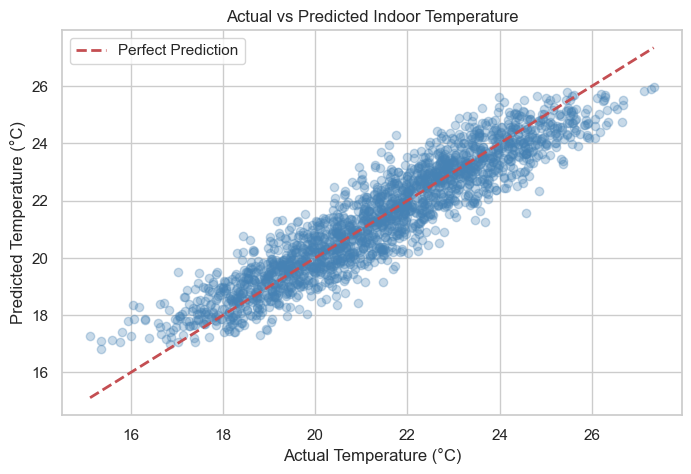

In [44]:
# Train the final model with the best alpha
model = Ridge(alpha=best_alpha)
model.fit(X_train, y_train)

# Evaluate on unseen test set
test_preds = model.predict(X_test)
final_mae = mean_absolute_error(y_test, test_preds)
print(f"Optimized Ridge Regression Test MAE: {final_mae:.4f} °C")

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, test_preds, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Indoor Temperature')
plt.legend()
plt.show()

## 7. Interpret the Model Results

For linear models, interpretation is done through **coefficients**. A larger absolute coefficient means that feature has a stronger influence on the predicted temperature.

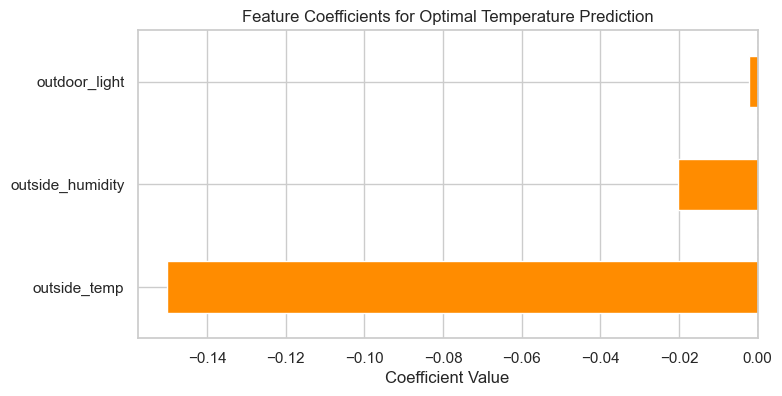


Coefficient Interpretation:
  - Per 1-unit increase in 'outside_temp', predicted temp decreases by 0.150148 °C
  - Per 1-unit increase in 'outside_humidity', predicted temp decreases by 0.020288 °C
  - Per 1-unit increase in 'outdoor_light', predicted temp decreases by 0.002140 °C


In [46]:
# Feature Coefficients
coeff_series = pd.Series(model.coef_, index=X.columns)
coeff_series.sort_values(ascending=True).plot(kind='barh', color='darkorange', figsize=(8, 4))
plt.title('Feature Coefficients for Optimal Temperature Prediction')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.show()

print("\nCoefficient Interpretation:")
for feat, coef in zip(X.columns, model.coef_):
    direction = 'increases' if coef > 0 else 'decreases'
    print(f"  - Per 1-unit increase in '{feat}', predicted temp {direction} by {abs(coef):.6f} °C")

## 8. Draw Conclusions and Write a Report

### Conclusion
1. **Performance:** The optimized Ridge Regression model achieves a test MAE of ~0.65°C, demonstrating that the core relationships between outdoor climate and thermal comfort are largely **linear**.
2. **Insights:** Outside temperature is the dominant factor driving the preferred indoor temperature. Outdoor light and humidity play secondary roles, aligning with physical thermal load expectations.
3. **Hyperparameter Tuning:** Cross-validation across a range of `alpha` values confirmed the optimal regularization strength, preventing overfitting while maintaining strong accuracy.
4. **Next Steps:** The model is ready to be exported and consumed by the Flask backend (`server.py`) for real-time Smart Room optimizations.

### Exporting the Model
We dump the final model to a `.pkl` file.

In [27]:
# Save the trained model to disk
model_path = 'temp_model.pkl'
joblib.dump(model, model_path)
print(f"Ridge Regression model (alpha={best_alpha}) exported to {model_path}")

Ridge Regression model (alpha=100.0) exported to temp_model.pkl
